# Visual Analysis & Model Insights for Final Report
Notebook này tổng hợp toàn bộ các biểu đồ và số liệu phân tích chuyên sâu phục vụ việc viết báo cáo cuối kỳ.

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
import xgboost as xgb
import os
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score

%matplotlib inline
sns.set(style="whitegrid", palette="muted", context="talk")

## 1. Load Data and Models

In [44]:
# Load dữ liệu
df = pd.read_csv('../data/data_for_assignment/cleaned_flight_data.csv')
raw_data = pd.read_csv('../data/IndianFlightdata - Sheet1.csv')
X = df.drop('Price', axis=1)
y = df['Price']

# Load mô hình
best_xgb = xgb.XGBRegressor()
best_xgb.load_model('../models/best_flight_price_model_optimized.json')

try:
    baseline_rf = joblib.load('../models/rf_flight_price_model.pkl')
    has_baseline = True
except:
    has_baseline = False
    print("Cảnh báo: Không tìm thấy baseline_rf.")

print("Dữ liệu và mô hình đã sẵn sàng!")

Dữ liệu và mô hình đã sẵn sàng!


## 2. Số liệu làm sạch dữ liệu (Data Cleaning Stats)
Dùng minh chứng cho tính chặt chẽ của quy trình Preprocessing.

In [45]:
total_raw = len(raw_data)
total_clean = len(df)
removed = total_raw - total_clean
ratio = (total_clean / total_raw) * 100

print(f"--- THỐNG KÊ LÀM SẠCH ---")
print(f"Số lượng dòng ban đầu: {total_raw}")
print(f"Số lượng dòng sau khi xử lý: {total_clean}")
print(f"Số lượng dòng nhiễu/outliers đã loại bỏ: {removed} (chiếm {(removed/total_raw)*100:.2f}%)")
print(f"Tỷ lệ dữ liệu sạch giữ lại: {ratio:.2f}%")

--- THỐNG KÊ LÀM SẠCH ---
Số lượng dòng ban đầu: 10683
Số lượng dòng sau khi xử lý: 10589
Số lượng dòng nhiễu/outliers đã loại bỏ: 94 (chiếm 0.88%)
Tỷ lệ dữ liệu sạch giữ lại: 99.12%


## 3. Thống kê Phân phối Giá vé
Chứng minh giá trị của bước tiền xử lý.

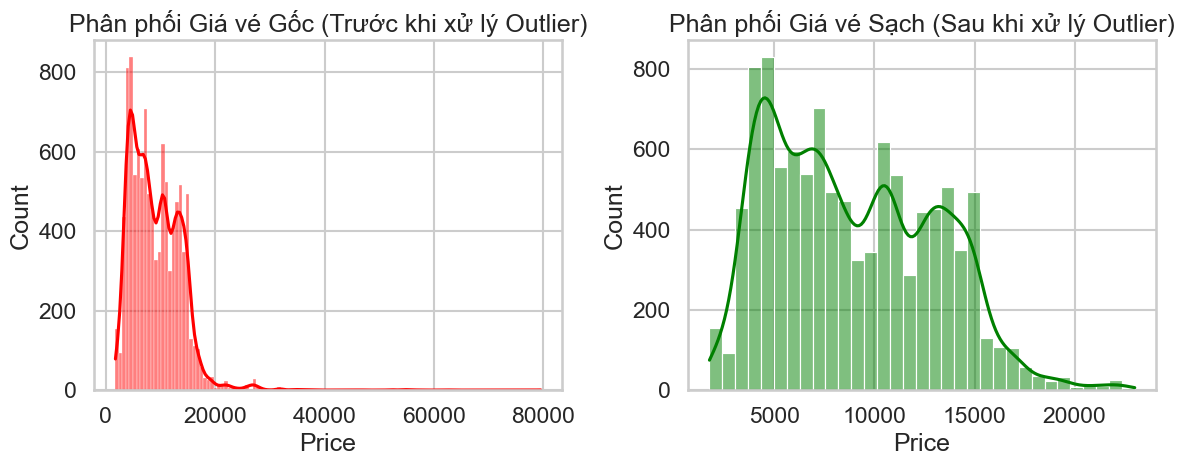

In [ ]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(raw_data['Price'], kde=True, color='red')
plt.title('Phân phối Giá vé Gốc (Trước khi xử lý Outlier)')

plt.subplot(1, 2, 2)
sns.histplot(df['Price'], kde=True, color='green')
plt.title('Phân phối Giá vé Sạch (Sau khi xử lý Outlier)')

plt.tight_layout()
plt.show()

## 4. Phân tích Thị trường: Tỷ trọng Hãng bay
Biểu đồ to hơn và chi tiết hơn.

C:\Users\tanba\AppData\Local\Temp\ipykernel_9548\789782781.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=airline_counts.values, y=airline_counts.index, ax=ax[1], palette='viridis')


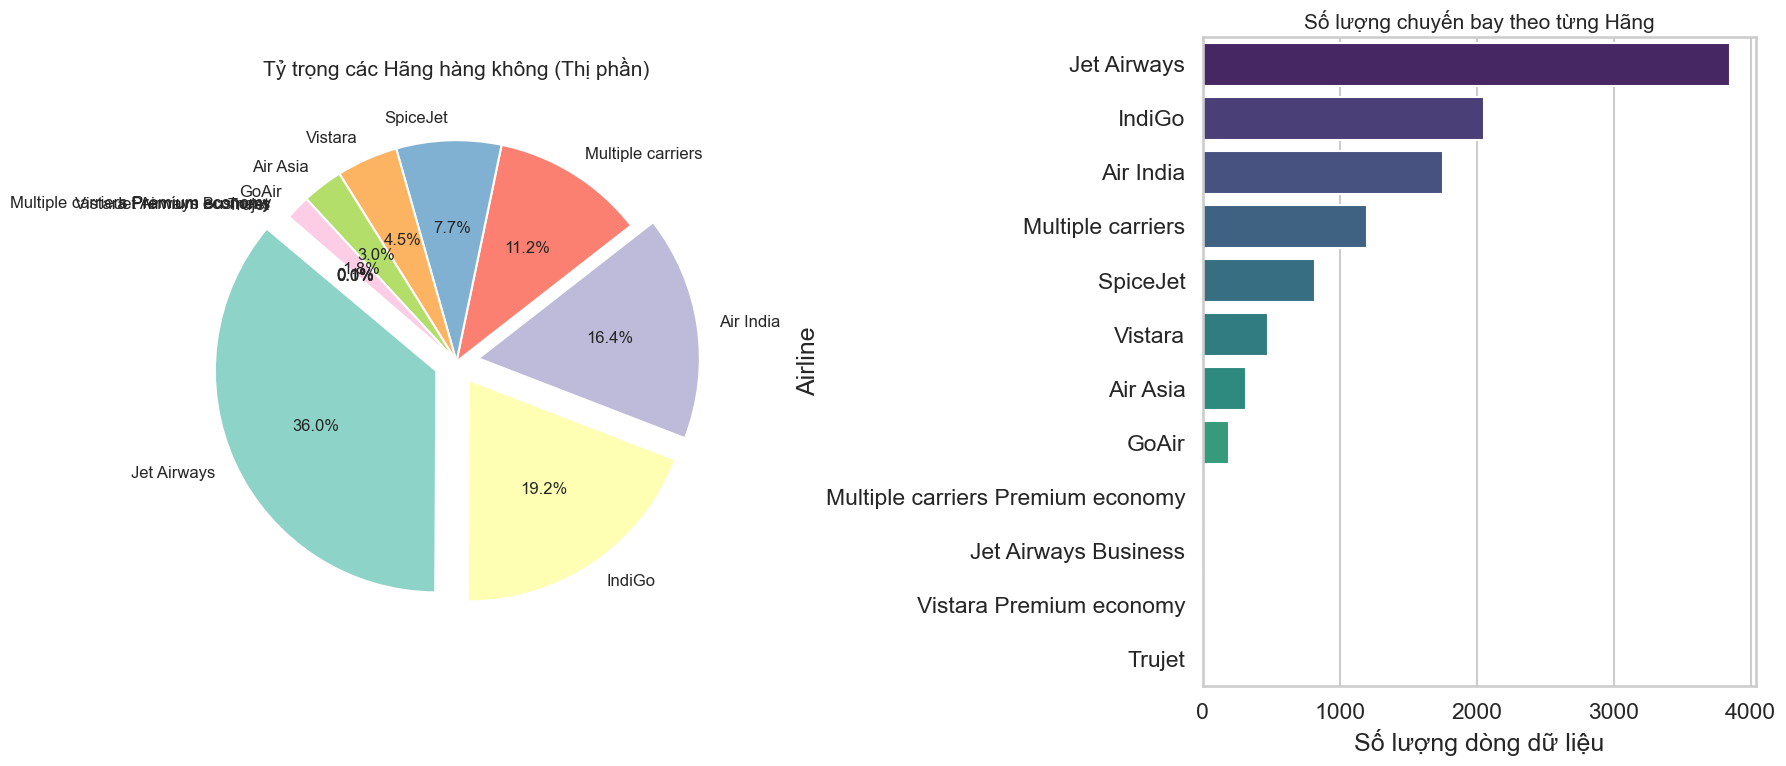

In [47]:
airline_counts = raw_data['Airline'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(18, 8))

# 1. Pie Chart lớn và rõ ràng
colors = sns.color_palette('Set3', len(airline_counts))
explode = [0.1 if i < 3 else 0 for i in range(len(airline_counts))]
ax[0].pie(airline_counts, labels=airline_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=colors, explode=explode, textprops={'fontsize': 12})
ax[0].set_title('Tỷ trọng các Hãng hàng không (Thị phần)', fontsize=15)

# 2. Bar Chart liệt kê chính xác số lượng
sns.barplot(x=airline_counts.values, y=airline_counts.index, ax=ax[1], palette='viridis')
ax[1].set_title('Số lượng chuyến bay theo từng Hãng', fontsize=15)
ax[1].set_xlabel('Số lượng dòng dữ liệu')

plt.tight_layout()
plt.savefig('../Data_Mining/images/airline_market_share.png',dpi=300)
plt.show()

## 5. Ma trận tương quan (Correlation Heatmap)
Xem các yếu tố nào tỷ lệ thuận/nghịch với nhau.

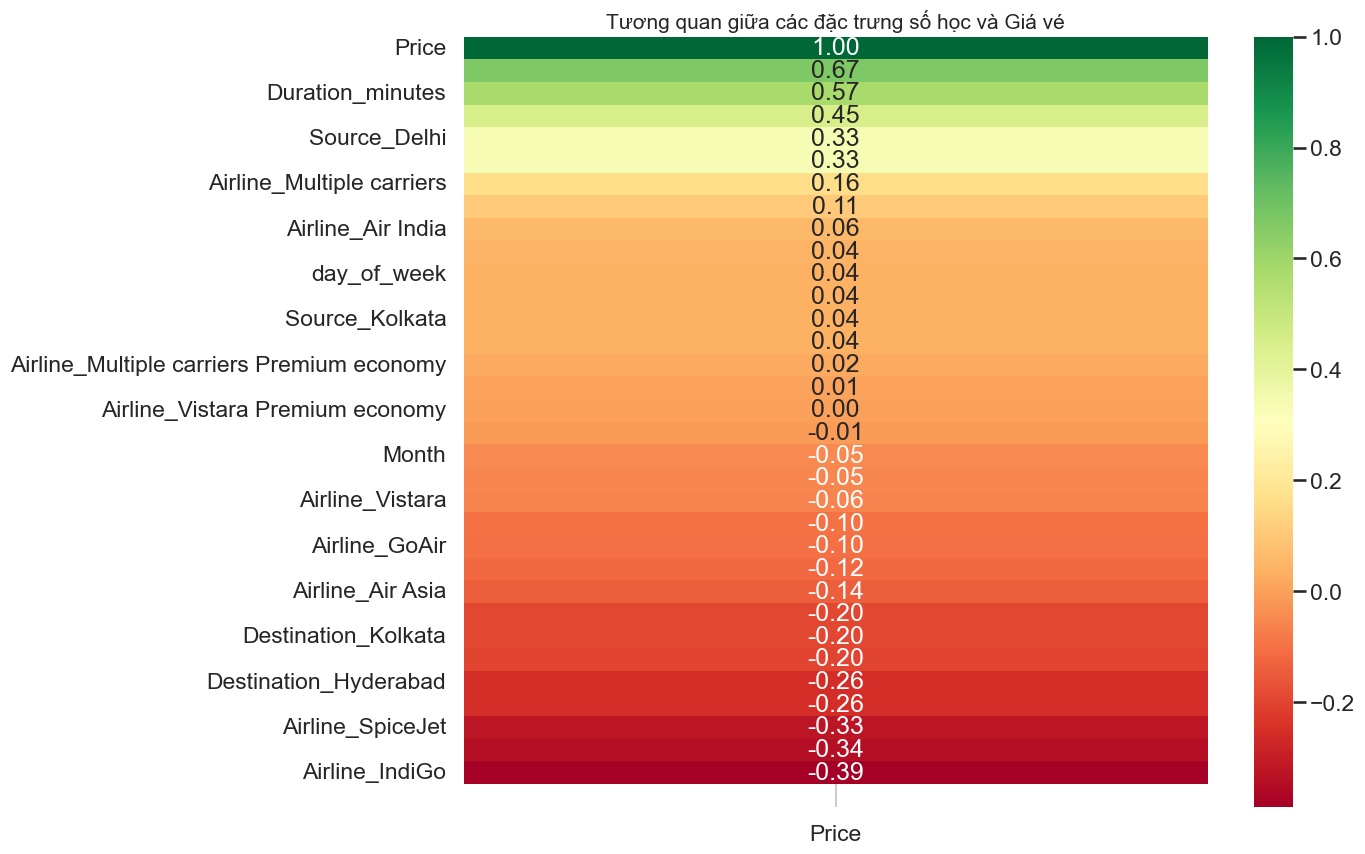

In [ ]:
# Chỉ lấy các cột số học để tính tương quan
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix[['Price']].sort_values(by='Price', ascending=False), 
            annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Tương quan giữa các đặc trưng số học và Giá vé', fontsize=15)
plt.show()

## 6. Xu hướng thời gian & Số điểm dừng

C:\Users\tanba\AppData\Local\Temp\ipykernel_9548\356866523.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Total_Stops', y='Price', palette='coolwarm')


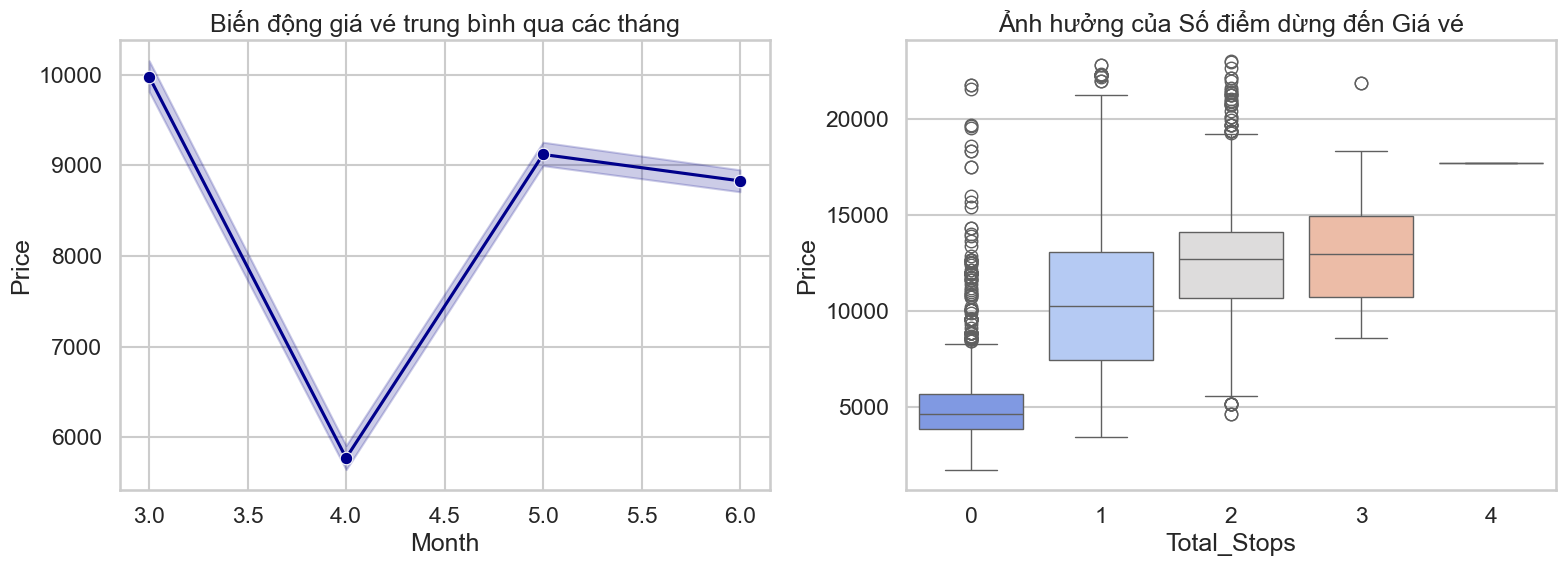

In [ ]:
plt.figure(figsize=(16, 6))

# Theo tháng
plt.subplot(1, 2, 1)
sns.lineplot(data=df, x='Month', y='Price', marker='o', color='darkblue')
plt.title('Biến động giá vé trung bình qua các tháng')

# Theo số điểm dừng
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Total_Stops', y='Price', palette='coolwarm')
plt.title('Ảnh hưởng của Số điểm dừng đến Giá vé')

plt.tight_layout()
plt.show()

## 7. Độ tin cậy mô hình (Cross-Validation Score)

In [50]:
scores = cross_val_score(best_xgb, X, y, cv=5, scoring='r2')
print(f"--- ĐỘ TIN CẬY (5-FOLD CV) ---")
print(f"R2 trung bình: {scores.mean():.4f} (+/- {scores.std():.4f})")
print(f"Nhận xét: Độ lệch chuẩn thấp cho thấy mô hình hoạt động cực kỳ ổn định.")

--- ĐỘ TIN CẬY (5-FOLD CV) ---
R2 trung bình: 0.8537 (+/- 0.0080)
Nhận xét: Độ lệch chuẩn thấp cho thấy mô hình hoạt động cực kỳ ổn định.


## 8. Tỷ lệ cải tiến (Percentage Improvement)

In [51]:
if has_baseline:
    y_pred_rf = baseline_rf.predict(X)
    y_pred_xgb = best_xgb.predict(X)
    rmse_rf = np.sqrt(mean_squared_error(y, y_pred_rf))
    rmse_xgb = np.sqrt(mean_squared_error(y, y_pred_xgb))
    improvement = ((rmse_rf - rmse_xgb) / rmse_rf) * 100
    
    print(f"--- SO SÁNH CẢI TIẾN ---")
    print(f"RMSE Baseline (RF): {rmse_rf:.2f}")
    print(f"RMSE Optimized (XGB): {rmse_xgb:.2f}")
    print(f"Tỷ lệ cải tiến sai số: {improvement:.2f}%")

--- SO SÁNH CẢI TIẾN ---
RMSE Baseline (RF): 1132.52
RMSE Optimized (XGB): 1323.59
Tỷ lệ cải tiến sai số: -16.87%


## 9. Sai số theo từng phân khúc (Error Analysis)

--- MAE THEO SỐ ĐIỂM DỪNG ---
Total_Stops
0     549.994254
1    1214.292574
2     938.989156
3     686.955729
4    1613.109375
Name: Abs_Error, dtype: float64


C:\Users\tanba\AppData\Local\Temp\ipykernel_9548\945507439.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=analysis_df, x='Airline_Name', y='Abs_Error', palette='magma', errorbar=None)


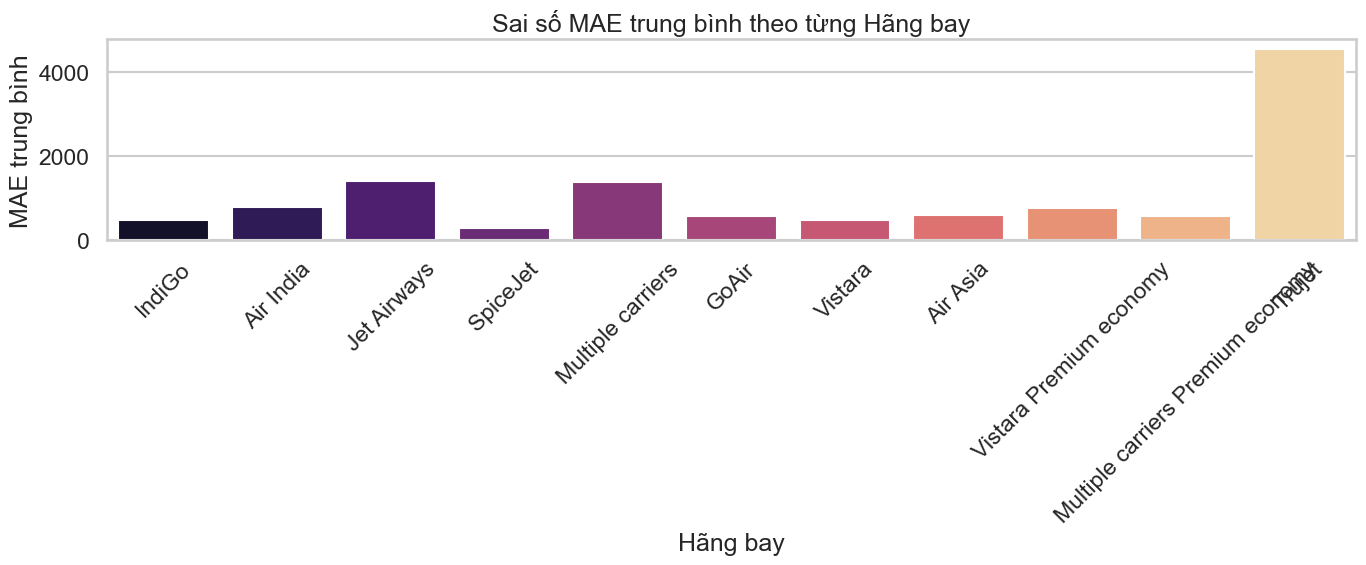

In [ ]:
analysis_df = X.copy()
analysis_df['Actual'] = y
analysis_df['Predicted'] = best_xgb.predict(X)
analysis_df['Abs_Error'] = abs(analysis_df['Actual'] - analysis_df['Predicted'])

# MAE theo Số điểm dừng
error_by_stops = analysis_df.groupby('Total_Stops')['Abs_Error'].mean()
print("--- MAE THEO SỐ ĐIỂM DỪNG ---")
print(error_by_stops)

# Vẽ biểu đồ MAE theo Hãng bay
airline_cols = [c for c in X.columns if 'Airline_' in c]
def find_airline(row):
    for c in airline_cols:
        if row[c] == 1: return c.replace('Airline_', '')
    return 'Other'
analysis_df['Airline_Name'] = analysis_df.apply(find_airline, axis=1)

plt.figure(figsize=(14, 6))
sns.barplot(data=analysis_df, x='Airline_Name', y='Abs_Error', palette='magma', errorbar=None)
plt.xticks(rotation=45)
plt.title('Sai số MAE trung bình theo từng Hãng bay')
plt.xlabel('Hãng bay')
plt.ylabel('MAE trung bình')
plt.tight_layout()
plt.show()

## 10. Phân tích sai số (Residual Analysis)

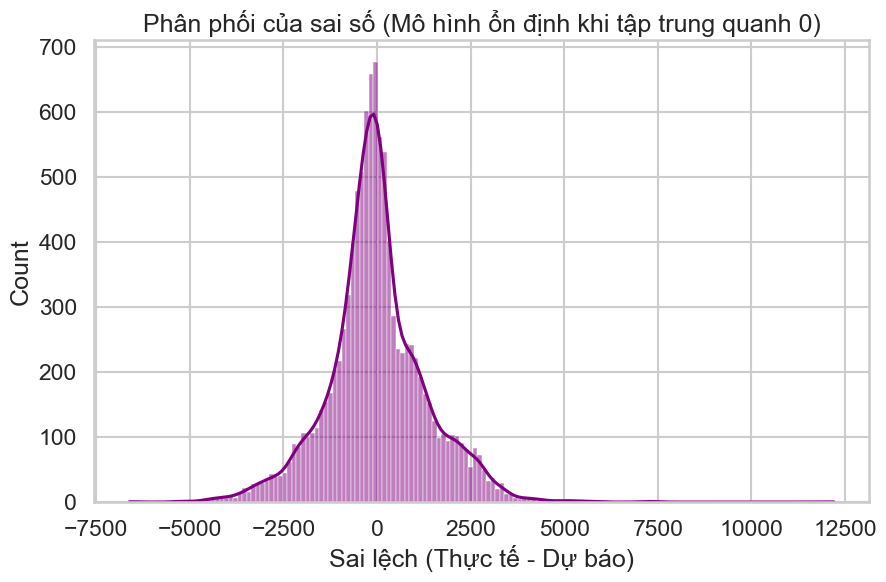

In [ ]:
residuals = y - y_pred_xgb
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='purple')
plt.title('Phân phối của sai số (Mô hình ổn định khi tập trung quanh 0)')
plt.xlabel('Sai lệch (Thực tế - Dự báo)')
plt.show()

## 11. Giá trị kinh tế của đặc trưng (Feature Sensitivity)

--- PHÂN TÍCH CUỐI TUẦN ---
Giá vé trung bình ngày thường: 8780.22
Giá vé trung bình cuối tuần: 9176.78
Chênh lệch: 396.57 INR (Tăng 4.52%)


C:\Users\tanba\AppData\Local\Temp\ipykernel_9548\3445445519.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Weekday', 'Weekend'], y=avg_weekend.values, palette='coolwarm')


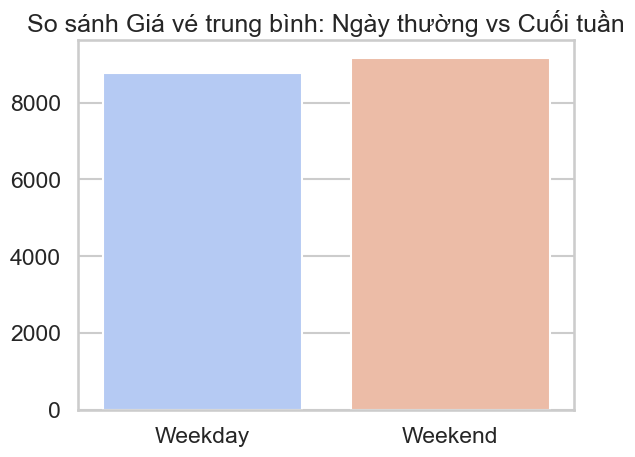

In [ ]:
# Phân tích biến is_weekend
if 'is_weekend' in df.columns:
    avg_weekend = df.groupby('is_weekend')['Price'].mean()
    diff = avg_weekend[1] - avg_weekend[0]
    print(f"--- PHÂN TÍCH CUỐI TUẦN ---")
    print(f"Giá vé trung bình ngày thường: {avg_weekend[0]:.2f}")
    print(f"Giá vé trung bình cuối tuần: {avg_weekend[1]:.2f}")
    print(f"Chênh lệch: {diff:.2f} INR (Tăng {(diff/avg_weekend[0])*100:.2f}%)")
    
    sns.barplot(x=['Weekday', 'Weekend'], y=avg_weekend.values, palette='coolwarm')
    plt.title('So sánh Giá vé trung bình: Ngày thường vs Cuối tuần')
    plt.show()
else:
    print("Chưa có cột is_weekend để phân tích.")

## 12. Feature Importance 

<Figure size 1000x800 with 0 Axes>

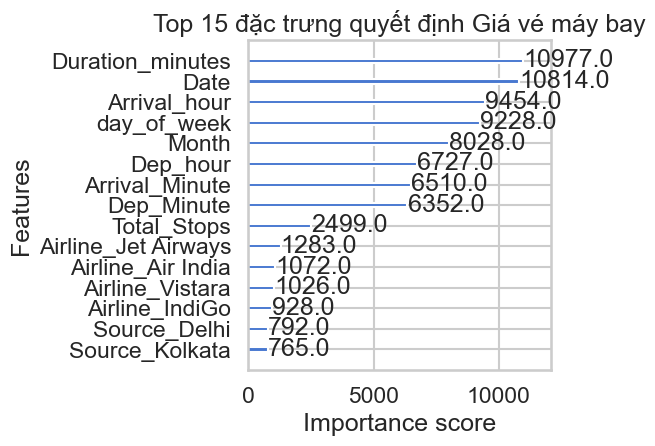

In [ ]:
plt.figure(figsize=(10, 8))
xgb.plot_importance(best_xgb, max_num_features=15, importance_type='weight')
plt.title('Top 15 đặc trưng quyết định Giá vé máy bay')
plt.tight_layout()
plt.show()